# Paper Figure Generation from Saved Outputs

This notebook recreates the paper visualizations from copied evaluation outputs in `updated_159.ipynb`. It does not rerun model training, embedding, retrieval, T5 generation, or diffusion evaluation.

Run the cells top to bottom. Figures are saved into `paper/figures/` and can be included by `main.tex`.

In [8]:
from pathlib import Path
import os
import sys, subprocess

try:
    import numpy as np
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy', 'matplotlib'])
    import numpy as np
    import matplotlib.pyplot as plt

# Colab/Jupyter kernels save relative paths from their current working directory,
# which may be /content instead of the folder that contains this notebook.
# Prefer the paper directory when it is visible; otherwise save to ./figures.
CWD = Path.cwd()
if (CWD / 'main.tex').exists():
    PAPER_DIR = CWD
elif (CWD / 'paper' / 'main.tex').exists():
    PAPER_DIR = CWD / 'paper'
else:
    PAPER_DIR = CWD

OUT = PAPER_DIR / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
print(f'Current working directory: {CWD}')
print(f'Figures will be saved to: {OUT.resolve()}')

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

COLORS = {
    'raw': '#1f77b4',
    'diff': '#ff7f0e',
    'a': '#2ca02c',
    'b': '#ff7f0e',
    'ensemble': '#9467bd',
    'oracle': '#7f7f7f',
    'delta': '#d62728',
}

def label_bars(ax, bars, fmt='{:.3f}', dy=3):
    for bar in bars:
        h = bar.get_height()
        if np.isnan(h):
            continue
        ax.annotate(fmt.format(h),
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, dy), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

def savefig(name):
    path = OUT / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f'Saved {path.resolve()}')

Current working directory: /content
Figures will be saved to: /content/figures


## Copied evaluation outputs

These values are copied from the finished output cells in `updated_159.ipynb`, ignoring later inactivity errors.

In [9]:
simple_summary = {
    'Raw SBERT': 0.1784,
    'Approach A': 0.1951,      # A_n8
    'Approach B': 0.1948,      # B_t20_alpha0.75
    'Ensemble': 0.2003,
    'Top-5 Oracle': 0.6009,
}

t5_summary = {
    'Raw SBERT': 0.5160,
    'Approach A': 0.4640,      # real-turn-trained model on T5 queries
    'Approach B': 0.5240,
    'Ensemble': np.nan,
    'Top-5 Oracle': 0.6760,
}

approach_rows = [
    {'approach': 'A n=1', 'raw': 0.1784, 'diff': 0.1678, 'delta': -0.0106},
    {'approach': 'A n=4', 'raw': 0.1784, 'diff': 0.1842, 'delta':  0.0058},
    {'approach': 'A n=8', 'raw': 0.1784, 'diff': 0.1951, 'delta':  0.0167},
    {'approach': 'B t=1', 'raw': 0.1784, 'diff': 0.1808, 'delta':  0.0024},
    {'approach': 'B t=3', 'raw': 0.1784, 'diff': 0.1829, 'delta':  0.0045},
    {'approach': 'B t=5', 'raw': 0.1784, 'diff': 0.1845, 'delta':  0.0061},
    {'approach': 'B t=10', 'raw': 0.1784, 'diff': 0.1859, 'delta':  0.0075},
    {'approach': 'B t=20', 'raw': 0.1784, 'diff': 0.1916, 'delta':  0.0132},
    {'approach': 'B t=20 a=.25', 'raw': 0.1784, 'diff': 0.1864, 'delta': 0.0080},
    {'approach': 'B t=20 a=.50', 'raw': 0.1784, 'diff': 0.1915, 'delta': 0.0131},
    {'approach': 'B t=20 a=.75', 'raw': 0.1784, 'diff': 0.1948, 'delta': 0.0164},
    {'approach': 'B t=20 a=1.0', 'raw': 0.1784, 'diff': 0.1938, 'delta': 0.0153},
]

topk_rows = [
    {'K': 3, 'raw': 0.1784, 'diff': 0.1897, 'delta': 0.0113, 'oracle': 0.4245},
    {'K': 5, 'raw': 0.1784, 'diff': 0.1920, 'delta': 0.0136, 'oracle': 0.6009},
    {'K': 10, 'raw': 0.1784, 'diff': 0.1935, 'delta': 0.0150, 'oracle': 0.8704},
    {'K': 20, 'raw': 0.1784, 'diff': 0.1947, 'delta': 0.0163, 'oracle': 0.9996},
]

query_type_rows = [
    {'query_type': 'Important fact', 'n': 14999, 'raw': 0.1057, 'diff': 0.1142, 'delta':  0.0085},
    {'query_type': 'Enjoys or likes', 'n': 10821, 'raw': 0.2135, 'diff': 0.2336, 'delta':  0.0201},
    {'query_type': 'Has', 'n': 4516, 'raw': 0.0996, 'diff': 0.1373, 'delta':  0.0376},
    {'query_type': 'Work', 'n': 1626, 'raw': 0.4619, 'diff': 0.4569, 'delta': -0.0049},
    {'query_type': 'Lives/from', 'n': 1306, 'raw': 0.5306, 'diff': 0.4893, 'delta': -0.0413},
    {'query_type': 'Plays', 'n': 324, 'raw': 0.5617, 'diff': 0.5494, 'delta': -0.0123},
    {'query_type': 'Studies', 'n': 33, 'raw': 0.8182, 'diff': 0.8182, 'delta':  0.0000},
]

mcnemar_counts = {
    'Both correct': 4069,
    'Both wrong': 25249,
    'Raw only correct': 1930,
    'Diff only correct': 2377,
}
mcnemar_stats = {'chi2': 46.18, 'p': 1.08e-11, 'delta': 0.0133, 'ci_low': 0.0094, 'ci_high': 0.0171}

## Figure 1: Combined simple-query and T5-query evaluation

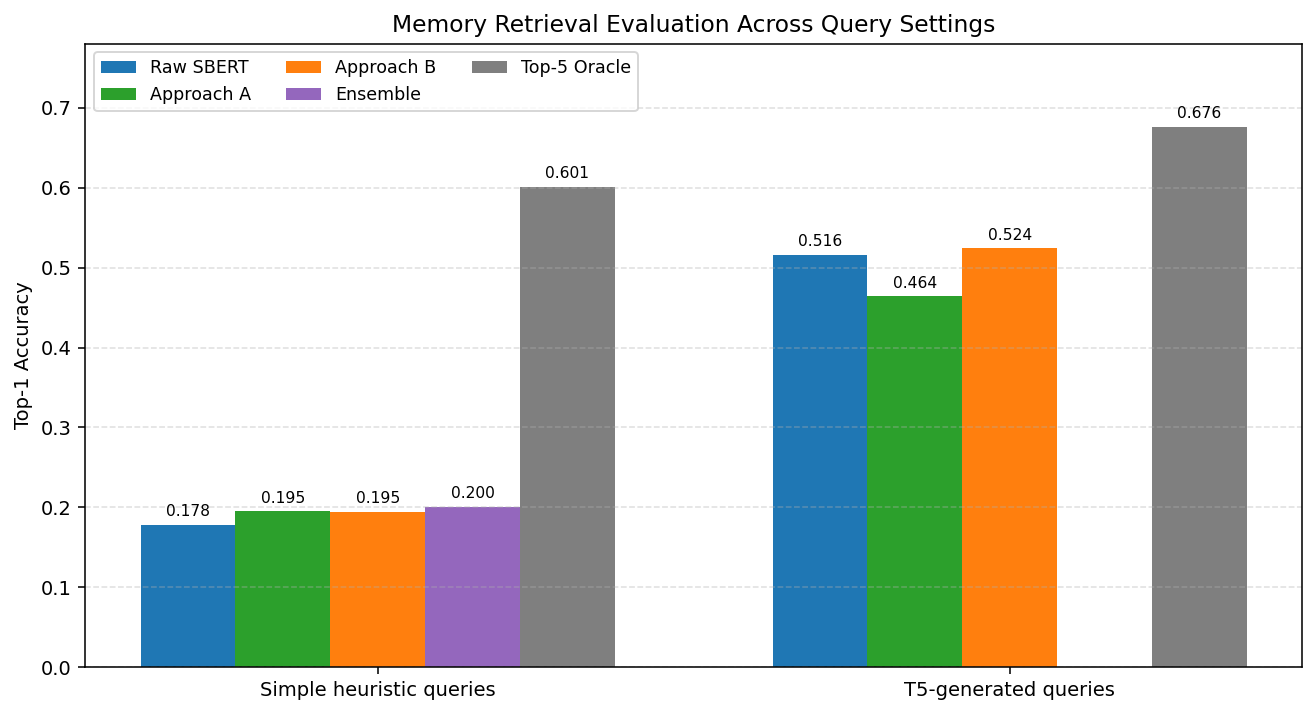

Saved /content/figures/paper_eval_simple_t5.png


In [10]:
metrics = ['Raw SBERT', 'Approach A', 'Approach B', 'Ensemble', 'Top-5 Oracle']
groups = [('Simple heuristic queries', simple_summary), ('T5-generated queries', t5_summary)]
x = np.arange(len(groups))
width = 0.15

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for i, metric in enumerate(metrics):
    vals = [g[1][metric] for g in groups]
    offset = (i - (len(metrics)-1)/2) * width
    color = {'Raw SBERT': COLORS['raw'], 'Approach A': COLORS['a'], 'Approach B': COLORS['b'], 'Ensemble': COLORS['ensemble'], 'Top-5 Oracle': COLORS['oracle']}[metric]
    bars = ax.bar(x + offset, vals, width, label=metric, color=color)
    label_bars(ax, bars)

ax.set_title('Memory Retrieval Evaluation Across Query Settings')
ax.set_ylabel('Top-1 Accuracy')
ax.set_xticks(x)
ax.set_xticklabels([g[0] for g in groups])
ax.set_ylim(0, 0.78)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(ncol=3, loc='upper left')
savefig('paper_eval_simple_t5.png')

## Figure 2: Raw, diffusion, and delta by approach

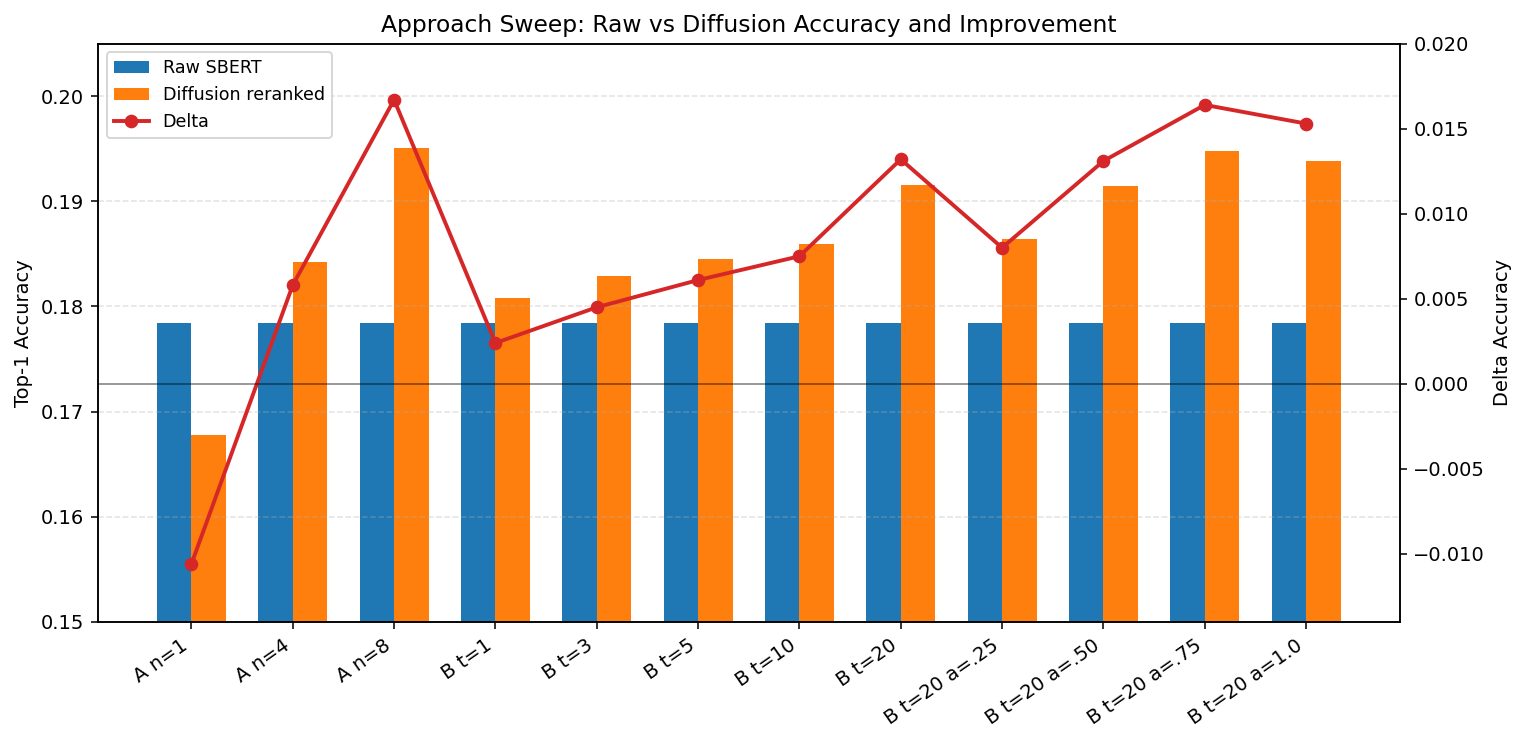

Saved /content/figures/paper_approach_raw_diff_delta.png


In [11]:
labels = [r['approach'] for r in approach_rows]
raw = np.array([r['raw'] for r in approach_rows])
diff = np.array([r['diff'] for r in approach_rows])
delta = np.array([r['delta'] for r in approach_rows])
x = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(11, 5.4))
w = 0.34
bars1 = ax1.bar(x - w/2, raw, w, label='Raw SBERT', color=COLORS['raw'])
bars2 = ax1.bar(x + w/2, diff, w, label='Diffusion reranked', color=COLORS['diff'])
ax1.set_ylabel('Top-1 Accuracy')
ax1.set_ylim(0.15, 0.205)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=35, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.35)

ax2 = ax1.twinx()
ax2.plot(x, delta, color=COLORS['delta'], marker='o', linewidth=2, label='Delta')
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.set_ylabel('Delta Accuracy')
ax2.set_ylim(-0.014, 0.020)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Approach Sweep: Raw vs Diffusion Accuracy and Improvement')
savefig('paper_approach_raw_diff_delta.png')

## Figure 3: Per-query-type accuracy

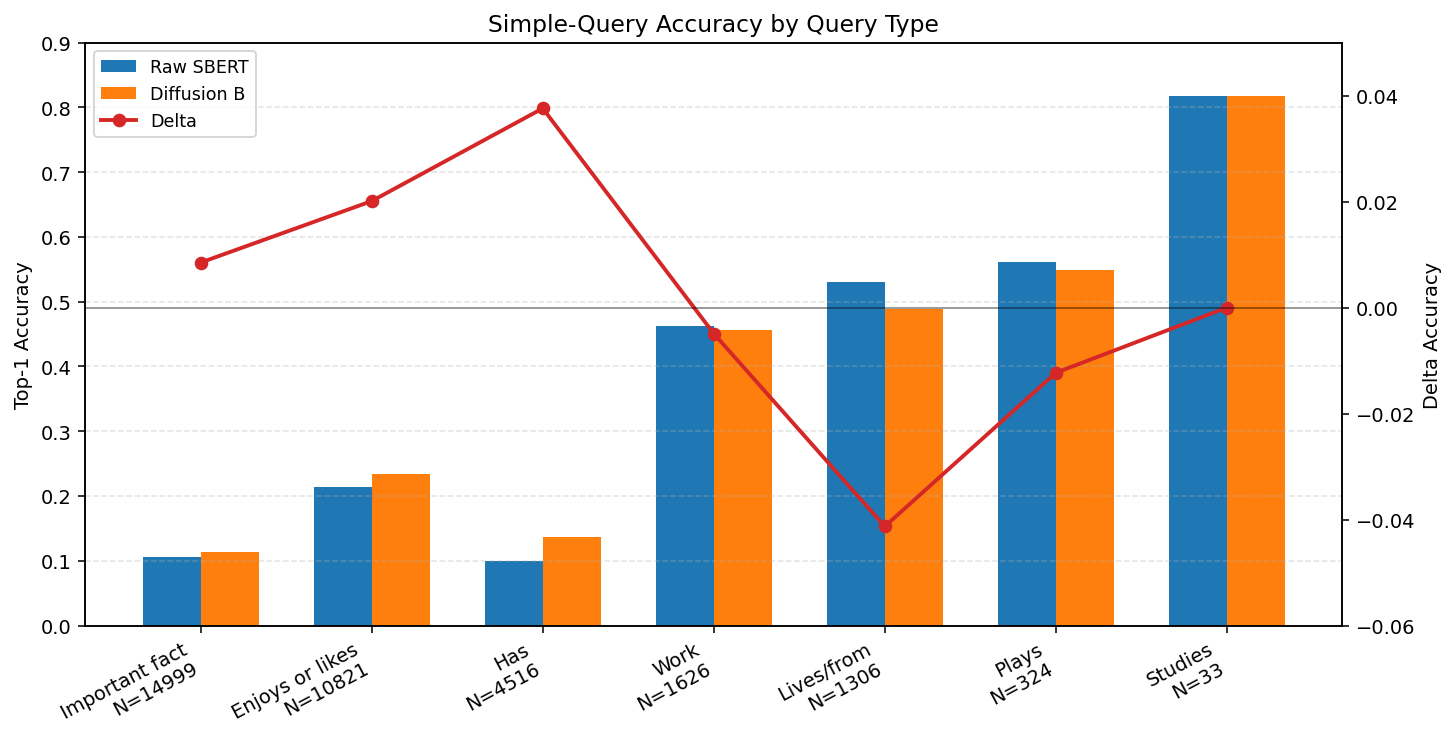

Saved /content/figures/paper_query_type_breakdown.png


In [12]:
rows = sorted(query_type_rows, key=lambda r: r['n'], reverse=True)
labels = [f"{r['query_type']}\nN={r['n']}" for r in rows]
raw = np.array([r['raw'] for r in rows])
diff = np.array([r['diff'] for r in rows])
delta = np.array([r['delta'] for r in rows])
x = np.arange(len(rows))

fig, ax1 = plt.subplots(figsize=(10.5, 5.5))
w = 0.34
ax1.bar(x - w/2, raw, w, label='Raw SBERT', color=COLORS['raw'])
ax1.bar(x + w/2, diff, w, label='Diffusion B', color=COLORS['diff'])
ax1.set_ylabel('Top-1 Accuracy')
ax1.set_ylim(0, 0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=28, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.35)

ax2 = ax1.twinx()
ax2.plot(x, delta, marker='o', color=COLORS['delta'], linewidth=2, label='Delta')
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.set_ylabel('Delta Accuracy')
ax2.set_ylim(-0.06, 0.05)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.set_title('Simple-Query Accuracy by Query Type')
savefig('paper_query_type_breakdown.png')

## Figure 4: Top-K oracle headroom

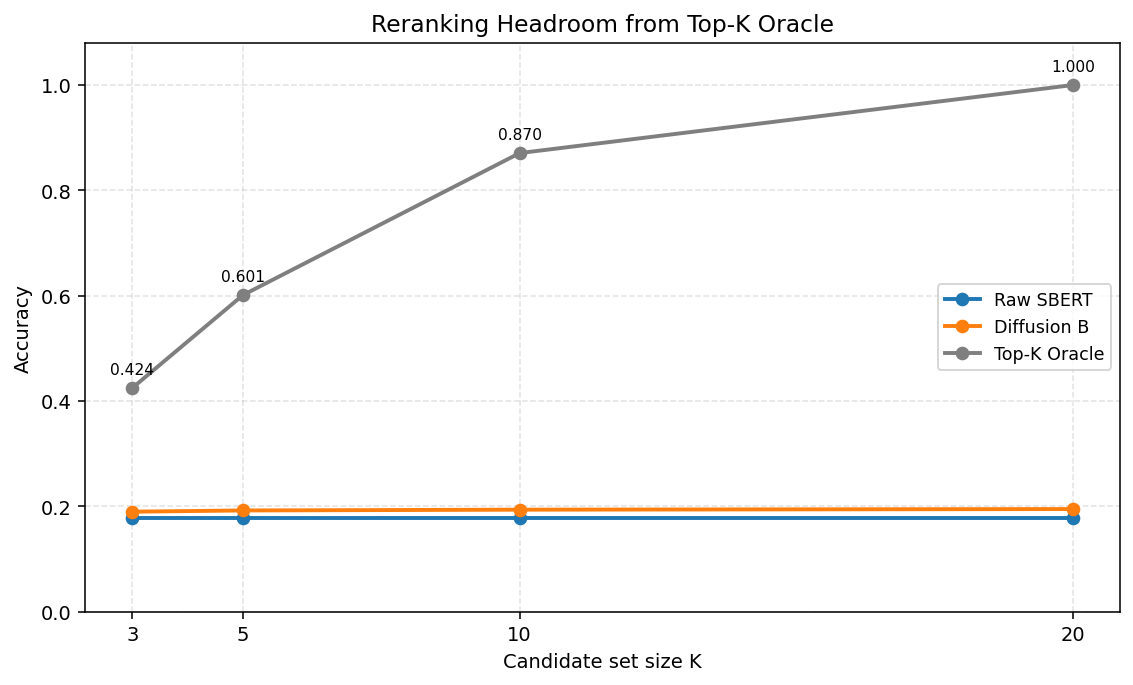

Saved /content/figures/paper_topk_oracle_headroom.png


In [13]:
ks = np.array([r['K'] for r in topk_rows])
raw = np.array([r['raw'] for r in topk_rows])
diff = np.array([r['diff'] for r in topk_rows])
oracle = np.array([r['oracle'] for r in topk_rows])

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(ks, raw, marker='o', linewidth=2, label='Raw SBERT', color=COLORS['raw'])
ax.plot(ks, diff, marker='o', linewidth=2, label='Diffusion B', color=COLORS['diff'])
ax.plot(ks, oracle, marker='o', linewidth=2, label='Top-K Oracle', color=COLORS['oracle'])
for xval, yval in zip(ks, oracle):
    ax.annotate(f'{yval:.3f}', (xval, yval), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)
ax.set_title('Reranking Headroom from Top-K Oracle')
ax.set_xlabel('Candidate set size K')
ax.set_ylabel('Accuracy')
ax.set_xticks(ks)
ax.set_ylim(0, 1.08)
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='center right')
savefig('paper_topk_oracle_headroom.png')

## Extra figure: paired decision changes

This is optional, but useful if the paper wants a fifth generated figure besides the saved `final_prediction.png`.

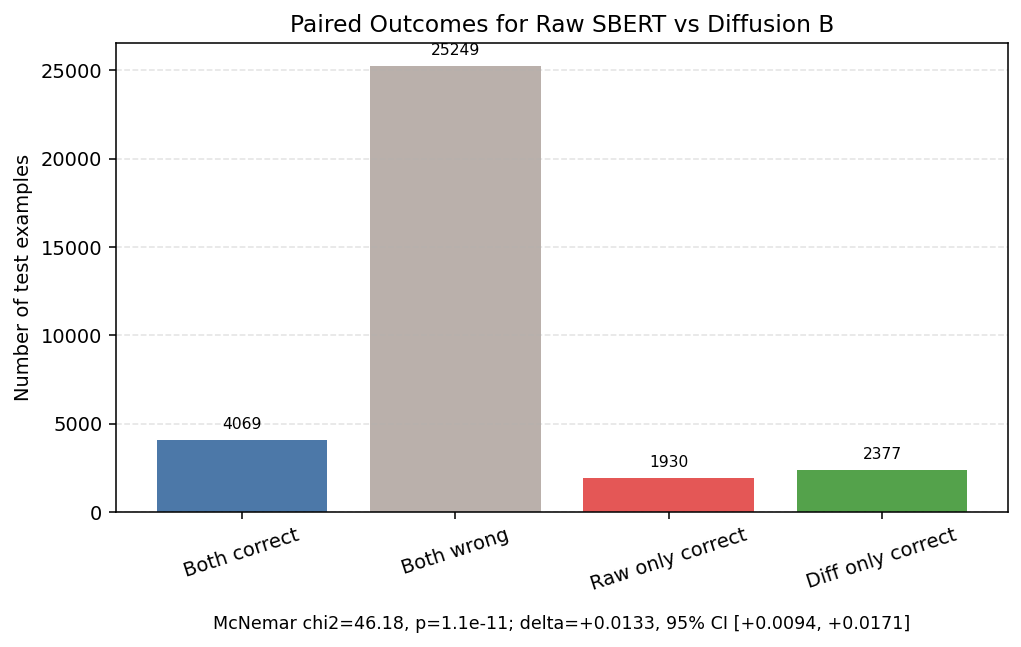

Saved /content/figures/paper_paired_outcomes.png


In [14]:
labels = list(mcnemar_counts.keys())
vals = np.array(list(mcnemar_counts.values()))
colors = ['#4c78a8', '#bab0ab', '#e45756', '#54a24b']

fig, ax = plt.subplots(figsize=(7.4, 4.8))
bars = ax.bar(labels, vals, color=colors)
label_bars(ax, bars, fmt='{:.0f}', dy=4)
ax.set_title('Paired Outcomes for Raw SBERT vs Diffusion B')
ax.set_ylabel('Number of test examples')
ax.tick_params(axis='x', rotation=18)
ax.grid(axis='y', linestyle='--', alpha=0.35)
subtitle = f"McNemar chi2={mcnemar_stats['chi2']:.2f}, p={mcnemar_stats['p']:.1e}; delta={mcnemar_stats['delta']:+.4f}, 95% CI [{mcnemar_stats['ci_low']:+.4f}, {mcnemar_stats['ci_high']:+.4f}]"
ax.text(0.5, -0.22, subtitle, transform=ax.transAxes, ha='center', va='top', fontsize=9)
savefig('paper_paired_outcomes.png')

In [15]:
!zip -r figures.zip figures
from google.colab import files
files.download("figures.zip")

  adding: figures/ (stored 0%)
  adding: figures/paper_query_type_breakdown.png (deflated 15%)
  adding: figures/paper_eval_simple_t5.png (deflated 23%)
  adding: figures/paper_approach_raw_diff_delta.png (deflated 16%)
  adding: figures/paper_topk_oracle_headroom.png (deflated 22%)
  adding: figures/paper_paired_outcomes.png (deflated 18%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>